In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
from google.colab import data_table
from vega_datasets import data
data_table.enable_dataframe_formatter()

In [3]:
##Import the modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
pd.set_option('display.max_columns', 500)
#df = pd.read_csv('Descriptor_GaBP2__20_Sep_24.csv')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/GaBP2/GaBP2_2024/4_SISSO_Phase_Electronegativity/Descriptor_GaBP2__20_Sep_24.csv')
df.head(2)

,compound,BandGap,Volume,ST,KT,CP,Allen_electneg_Avg,Allen_electneg_Min,Allen_electneg_Max,vand_rad_Avg,vand_rad_Min,vand_rad_Max,cov_rad_Avg,cov_rad_Min,cov_rad_Max,atom_rad_Avg,atom_rad_Min,atom_rad_Max,density_Avg,density_Min,density_Max
0,ZnGeN2,2.44,181.39,1,0,0,2.22,1.59,3.07,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13
1,ZnGeN2,3.02,181.83,0,1,0,2.22,1.59,3.07,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13


In [5]:
df1 = df.copy()

# `SISSO Formula`

In [6]:
import numpy as np
# Assuming df1 contains the required features:
# 'vand_rad_Min', 'Volume', 'atom_rad_Min', 'density_Avg', 'density_Min',
# 'atom_rad_Avg', 'vand_rad_Avg', 'cov_rad_Max', 'atom_rad_Max'

# Calculate the descriptors
df1['d001_No_Phase'] = np.exp(df1['vand_rad_Min'] / df1['Volume']) * (df1['atom_rad_Min'] / (df1['density_Avg'] + df1['density_Min']))

df1['d002_No_Phase'] = ((df1['atom_rad_Avg']**2 - df1['atom_rad_Min'] * df1['vand_rad_Avg']) / np.log(df1['density_Min']))

df1['d003_No_Phase'] = -np.exp(-df1['density_Avg']) / ((df1['atom_rad_Avg'] - df1['cov_rad_Max']) + (df1['atom_rad_Max'] - df1['cov_rad_Max']))

df1 = df1.round(2)

In [7]:
df1.head()

,compound,BandGap,Volume,ST,KT,CP,Allen_electneg_Avg,Allen_electneg_Min,Allen_electneg_Max,vand_rad_Avg,vand_rad_Min,vand_rad_Max,cov_rad_Avg,cov_rad_Min,cov_rad_Max,atom_rad_Avg,atom_rad_Min,atom_rad_Max,density_Avg,density_Min,density_Max,d001_No_Phase,d002_No_Phase,d003_No_Phase
0,ZnGeN2,2.44,181.39,1,0,0,2.22,1.59,3.07,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,26.74,-3767.73,0.02
1,ZnGeN2,3.02,181.83,0,1,0,2.22,1.59,3.07,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,26.69,-3767.73,0.02
2,ZnGeN2,2.73,181.56,0,0,1,2.22,1.59,3.07,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,26.72,-3767.73,0.02
3,AlGaN2,4.59,178.46,1,0,0,2.15,1.61,3.07,175.33,155,187,104.67,71,122,106.67,65,130,3.14,0.81,5.91,39.22,85.24,0.01
4,AlGaN2,4.63,178.36,0,1,0,2.15,1.61,3.07,175.33,155,187,104.67,71,122,106.67,65,130,3.14,0.81,5.91,39.24,85.24,0.01


# <mark> Bootstrapping  <mark>

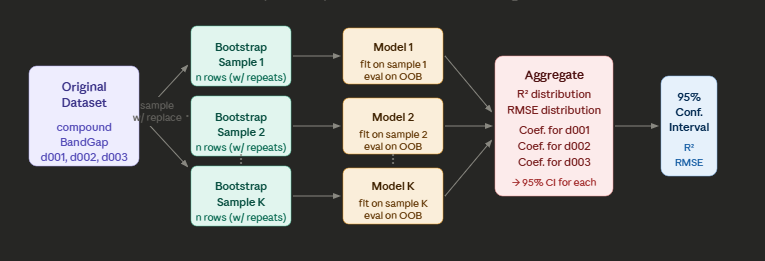

In [8]:
df1_No_Phase = df1[['compound', 'BandGap','d001_No_Phase','d002_No_Phase', 'd003_No_Phase']]
df1_No_Phase.head(2)

,compound,BandGap,d001_No_Phase,d002_No_Phase,d003_No_Phase
0,ZnGeN2,2.44,26.74,-3767.73,0.02
1,ZnGeN2,3.02,26.69,-3767.73,0.02


In [9]:
df1_No_Phase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   compound       92 non-null     object 
 1   BandGap        92 non-null     float64
 2   d001_No_Phase  92 non-null     float64
 3   d002_No_Phase  92 non-null     float64
 4   d003_No_Phase  92 non-null     float64
dtypes: float64(4), object(1)
memory usage: 3.7+ KB


In [10]:
df1_No_Phase.keys()

Index(['compound', 'BandGap', 'd001_No_Phase', 'd002_No_Phase',
       'd003_No_Phase'],
      dtype='object')

In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

df = df1_No_Phase.copy()

features = ['d001_No_Phase', 'd002_No_Phase', 'd003_No_Phase']
target = 'BandGap'

X = df[features].values
y = df[target].values

# --- Step 1: Find optimal alpha via 5-fold CV ---
scaler_full = StandardScaler()
X_sc = scaler_full.fit_transform(X)

lasso_cv = LassoCV(cv=5, max_iter=5000, random_state=42)
lasso_cv.fit(X_sc, y)
best_alpha = lasso_cv.alpha_
print(f"Optimal alpha (5-fold CV): {best_alpha:.4f}")

# --- Step 2: Bootstrap with optimal alpha ---
n_iterations = 1000
n_samples = len(X)

r2_scores, rmse_scores, coef_list = [], [], []
np.random.seed(42)

for i in range(n_iterations):
    idx = np.random.choice(n_samples, size=n_samples, replace=True)
    oob_idx = list(set(range(n_samples)) - set(idx))

    if len(oob_idx) == 0:
        continue

    X_train, y_train = X[idx], y[idx]
    X_oob,   y_oob   = X[oob_idx], y[oob_idx]

    # Scale inside loop — fit on train only, apply to OOB
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_oob_sc   = scaler.transform(X_oob)

    # Use optimal alpha found in Step 1
    model = Lasso(alpha=best_alpha, max_iter=5000)
    model.fit(X_train_sc, y_train)

    y_pred = model.predict(X_oob_sc)
    r2_scores.append(r2_score(y_oob, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_oob, y_pred)))
    coef_list.append(model.coef_)

# --- Step 3: Results ---
coef_array = np.array(coef_list)

print("\n=== LASSO Bootstrap Results ===")
print(f"R²   — Mean: {np.mean(r2_scores):.4f} | 95% CI: [{np.percentile(r2_scores, 2.5):.4f}, {np.percentile(r2_scores, 97.5):.4f}]")
print(f"RMSE — Mean: {np.mean(rmse_scores):.4f} | 95% CI: [{np.percentile(rmse_scores, 2.5):.4f}, {np.percentile(rmse_scores, 97.5):.4f}]")
print()
print("=== Feature Coefficients (standardized) ===")
for i, feat in enumerate(features):
    mean_c = np.mean(coef_array[:, i])
    ci_lo  = np.percentile(coef_array[:, i], 2.5)
    ci_hi  = np.percentile(coef_array[:, i], 97.5)
    zeroed = np.mean(coef_array[:, i] == 0) * 100
    print(f"{feat:20s} | coef: {mean_c:+.4f} | 95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}] | zeroed out: {zeroed:.1f}%")

Optimal alpha (5-fold CV): 0.0011

=== LASSO Bootstrap Results ===
R²   — Mean: 0.9162 | 95% CI: [0.8440, 0.9639]
RMSE — Mean: 0.3214 | 95% CI: [0.2309, 0.4005]

=== Feature Coefficients (standardized) ===
d001_No_Phase        | coef: +1.0757 | 95% CI: [+0.9361, +1.2208] | zeroed out: 0.0%
d002_No_Phase        | coef: +0.1966 | 95% CI: [+0.1277, +0.2589] | zeroed out: 0.0%
d003_No_Phase        | coef: +0.1324 | 95% CI: [+0.0746, +0.1930] | zeroed out: 0.0%


In [12]:
# Optimal alpha (5-fold CV): 0.0011

# === LASSO Bootstrap Results ===
# R²   — Mean: 0.9162 | 95% CI: [0.8440, 0.9639]
# RMSE — Mean: 0.3214 | 95% CI: [0.2309, 0.4005]

# === Feature Coefficients (standardized) ===
# d001_No_Phase        | coef: +1.0757 | 95% CI: [+0.9361, +1.2208] | zeroed out: 0.0%
# d002_No_Phase        | coef: +0.1966 | 95% CI: [+0.1277, +0.2589] | zeroed out: 0.0%
# d003_No_Phase        | coef: +0.1324 | 95% CI: [+0.0746, +0.1930] | zeroed out: 0.0%

In [13]:
y_oob.shape

(30,)

In [14]:
X_oob.shape

(30, 3)

In [15]:
X_train.shape

(92, 3)

In [16]:
X_oob_sc.shape

(30, 3)

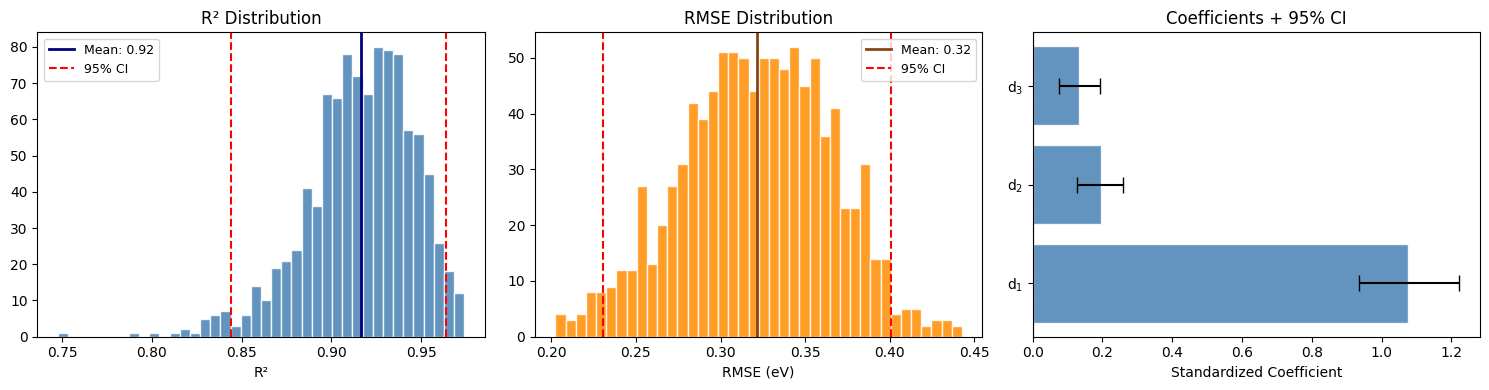

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#fig.suptitle("LASSO Bootstrap Analysis", fontsize=13)

# --- Plot 1: R² distribution ---
axes[0].hist(r2_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(r2_scores), color='navy', lw=2, label=f'Mean: {np.mean(r2_scores):.2f}')
axes[0].axvline(np.percentile(r2_scores, 2.5),  color='red', lw=1.5, ls='--', label='95% CI')
axes[0].axvline(np.percentile(r2_scores, 97.5), color='red', lw=1.5, ls='--')
axes[0].set_title("R² Distribution"); axes[0].set_xlabel("R²"); axes[0].legend(fontsize=9)

# --- Plot 2: RMSE distribution ---
axes[1].hist(rmse_scores, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(rmse_scores), color='saddlebrown', lw=2, label=f'Mean: {np.mean(rmse_scores):.2f}')
axes[1].axvline(np.percentile(rmse_scores, 2.5),  color='red', lw=1.5, ls='--', label='95% CI')
axes[1].axvline(np.percentile(rmse_scores, 97.5), color='red', lw=1.5, ls='--')
axes[1].set_title("RMSE Distribution"); axes[1].set_xlabel("RMSE (eV)"); axes[1].legend(fontsize=9)

# --- Plot 3: Coefficient CIs ---
feat_labels = ['d$_1$', 'd$_2$', 'd$_3$']
means  = [np.mean(coef_array[:, i]) for i in range(3)]
ci_low = [np.percentile(coef_array[:, i], 2.5)  for i in range(3)]
ci_hi  = [np.percentile(coef_array[:, i], 97.5) for i in range(3)]
colors = ['steelblue' if m > 0 else 'tomato' for m in means]
errors = [[m - l for m, l in zip(means, ci_low)],
          [h - m for m, h in zip(means, ci_hi)]]

axes[2].barh(feat_labels, means, xerr=errors, color=colors,
             edgecolor='white', alpha=0.85, capsize=6)
axes[2].axvline(0, color='black', lw=0.8, ls='--')
axes[2].set_title("Coefficients + 95% CI")
axes[2].set_xlabel("Standardized Coefficient")

plt.tight_layout()
plt.savefig("bootstrap_lasso_results.pdf", dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# from google.colab import files
# files.download("bootstrap_lasso_results.pdf")

In [19]:
df1.shape

(92, 24)

In [20]:
# Check actual OOB sizes across all iterations
n_samples = len(df1)  # 92 — always derive from data, never hardcode

oob_sizes = []
np.random.seed(42)

for i in range(1000):
    idx = np.random.choice(n_samples, size=n_samples, replace=True)
    oob_idx = list(set(range(n_samples)) - set(idx))
    oob_sizes.append(len(oob_idx))

print(f"Total rows         : {n_samples}")
print(f"Train (bootstrap)  : {n_samples} rows/iter (with repeats, ~{n_samples - int(np.mean(oob_sizes))} unique)")
print(f"OOB (test) — Mean  : {np.mean(oob_sizes):.1f} rows")
print(f"OOB (test) — Range : {min(oob_sizes)} to {max(oob_sizes)} rows")
print(f"OOB % of data      : {np.mean(oob_sizes)/n_samples*100:.1f}%")

Total rows         : 92
Train (bootstrap)  : 92 rows/iter (with repeats, ~59 unique)
OOB (test) — Mean  : 33.5 rows
OOB (test) — Range : 25 to 43 rows
OOB % of data      : 36.5%


In [21]:
# Total rows         : 92
# Train (bootstrap)  : 92 rows/iter (with repeats, ~59 unique)
# OOB (test) — Mean  : 33.5 rows
# OOB (test) — Range : 25 to 43 rows
# OOB % of data      : 36.5%

In [22]:
# Check actual OOB sizes across all iterations
n_samples = len(df1)  # 92

oob_sizes = []
np.random.seed(42)

for i in range(1000):
    idx = np.random.choice(n_samples, size=n_samples, replace=True)
    oob_idx = list(set(range(n_samples)) - set(idx))
    oob_sizes.append(len(oob_idx))

print(f"OOB (test) — Range : {min(oob_sizes)} to {max(oob_sizes)} rows")

OOB (test) — Range : 25 to 43 rows


In [23]:
#OOB (test) — Range : 25 to 43 rows